# Ultimate Data Analysis Challenge


## Objectives

**Part 1:** Aggregate login activity into 15-minute intervals and describe the main time-series patterns in demand.  
**Part 2:** Propose a success metric and a practical experiment to evaluate whether reimbursing tolls encourages driver partners to serve both cities.  
**Part 3:** Identify which rider characteristics are most predictive of long-term retention and explain how those insights could be used operationally.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
logins = pd.read_json("logins.json")
logins.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [4]:
ultimate = pd.read_json("ultimate_data_challenge.json")
ultimate.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [5]:
logins.info()
ultimate.info()
logins.isna().sum()
ultimate.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 727.8 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   we

city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
dtype: int64

## Part 1: Exploratory Data Analysis

The first part of the challenge examines the `logins.json` dataset, which contains individual login timestamps. The goal is to transform these raw event-level timestamps into a 15-minute time series and then visualize the patterns that best describe underlying demand. In addition to identifying recurring cycles, this section also checks for basic data quality issues such as missing values, duplicate timestamps, and unusual spikes.

### Data Cleaning and Preparation

Before aggregating the data, the login timestamps are converted into a proper datetime format and sorted chronologically. This ensures that the time series is ordered correctly and can be resampled into consistent 15-minute intervals. A brief quality check is also included to inspect the number of rows, the number of duplicate timestamps, and the overall time range covered by the dataset.

In [8]:
logins["login_time"] = pd.to_datetime(logins["login_time"])
logins = logins.sort_values("login_time")

In [9]:
print("Rows:", len(logins))
print("Duplicate timestamps:", logins.duplicated().sum())
print("Min time:", logins["login_time"].min())
print("Max time:", logins["login_time"].max())

Rows: 93142
Duplicate timestamps: 877
Min time: 1970-01-01 20:12:16
Max time: 1970-04-13 18:57:38


### Aggregating Logins into 15-Minute Intervals

To make the demand pattern easier to study, the raw login events are grouped into 15-minute buckets. Each time interval represents the total number of logins that occurred during that period. This transformation creates the core time series used for the rest of the analysis.

In [11]:
login_counts = (
    logins
    .set_index("login_time")
    .resample("15min")
    .size()
    .rename("login_count")
    .reset_index()
)

login_counts.head()

,login_time,login_count
0,1970-01-01 20:00:00,2
1,1970-01-01 20:15:00,6
2,1970-01-01 20:30:00,9
3,1970-01-01 20:45:00,7
4,1970-01-01 21:00:00,1


### Time Series of Login Demand

The first visualization shows the full login count time series across all 15-minute intervals. This plot is useful for identifying broad variation in demand over time, including periods of sustained activity, quieter periods, and any visible recurring structure. Because the plot spans the full date range, it is most useful for showing overall volatility and repetition rather than fine-grained hourly detail.

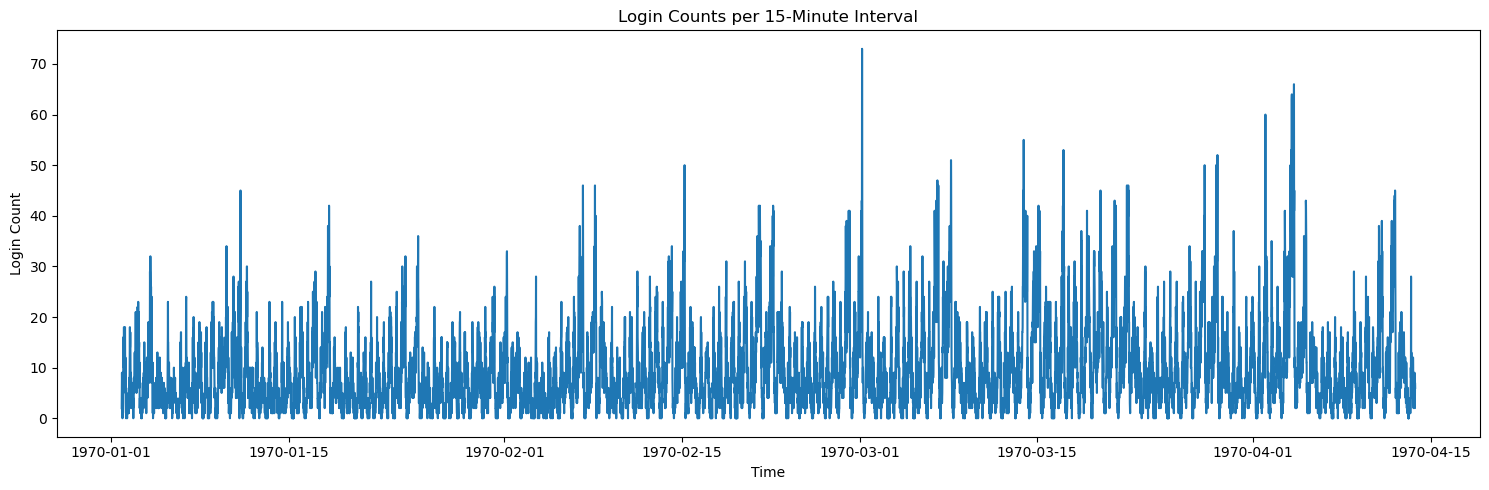

In [13]:
plt.figure(figsize=(15,5))
plt.plot(login_counts["login_time"], login_counts["login_count"])
plt.title("Login Counts per 15-Minute Interval")
plt.xlabel("Time")
plt.ylabel("Login Count")
plt.tight_layout()
plt.show()

### Extracting Time-Based Features

To better understand recurring patterns, several calendar-based features are created from the aggregated timestamps. These include hour of day, day name, day of week, and calendar date. These derived fields allow the analysis to compare activity across different hours and days rather than only looking at the raw timeline.

In [15]:
login_counts["hour"] = login_counts["login_time"].dt.hour
login_counts["day_name"] = login_counts["login_time"].dt.day_name()
login_counts["day_of_week"] = login_counts["login_time"].dt.dayofweek
login_counts["date"] = login_counts["login_time"].dt.date

### Average Login Count by Hour of Day

This chart summarizes the average login volume for each hour of the day. It is designed to reveal the daily cycle in demand and highlight the hours when activity is typically strongest or weakest. Looking at hourly averages makes it easier to separate true recurring patterns from one-off fluctuations in the raw time series.

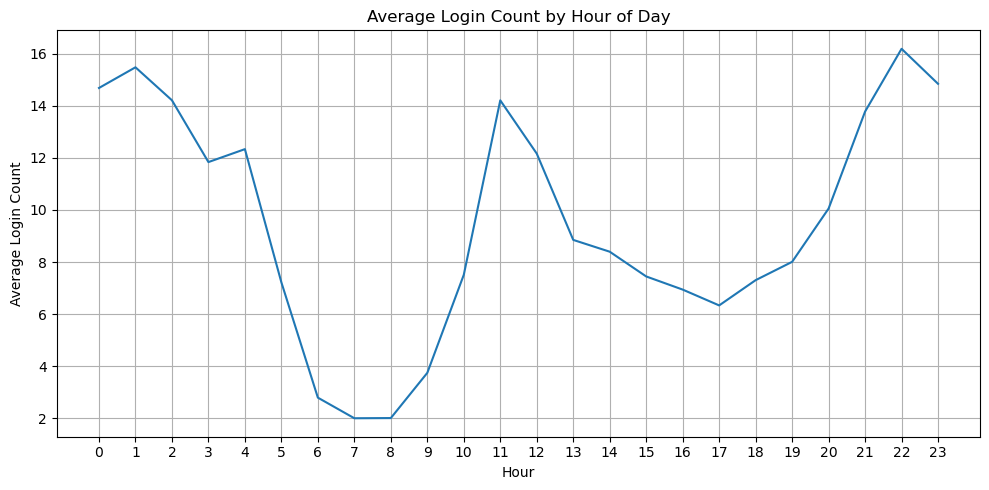

In [17]:
hourly_pattern = login_counts.groupby("hour")["login_count"].mean()

plt.figure(figsize=(10,5))
hourly_pattern.plot()
plt.title("Average Login Count by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Login Count")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

### Average Login Count by Day of Week

This visualization compares average demand across the days of the week. It helps determine whether demand is concentrated on weekdays, weekends, or specific transition days such as Friday. Since user behavior often changes meaningfully between workdays and leisure days, this view is especially helpful for identifying weekly seasonality.

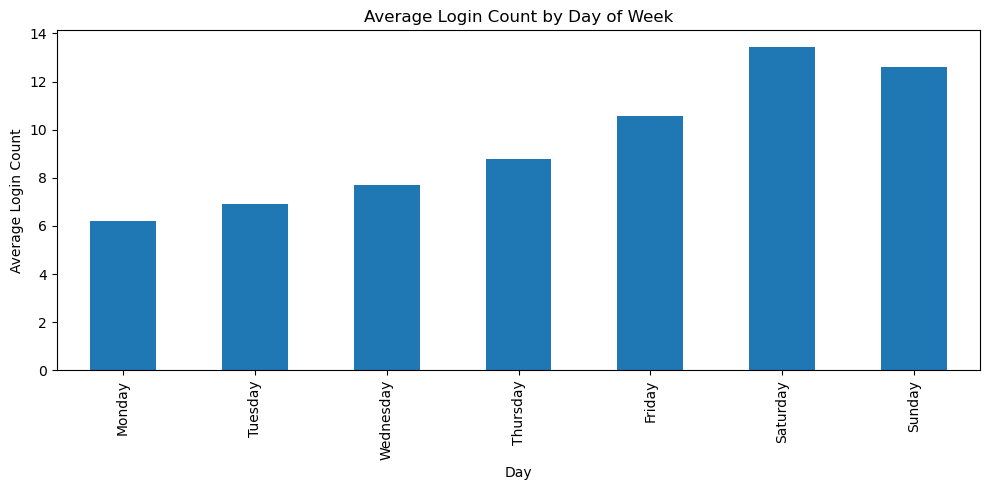

In [19]:
dow_pattern = login_counts.groupby("day_name")["login_count"].mean()
dow_pattern = dow_pattern.reindex([
    "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"
])

plt.figure(figsize=(10,5))
dow_pattern.plot(kind="bar")
plt.title("Average Login Count by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Login Count")
plt.tight_layout()
plt.show()

### Heatmap of Login Activity by Day and Hour

The heatmap combines the daily and weekly dimensions by showing average login demand for each hour of each day. This is one of the most useful summary visuals in the analysis because it shows exactly when demand is concentrated. It highlights whether peak periods occur late at night, during weekday midday hours, or during weekend overnight periods.

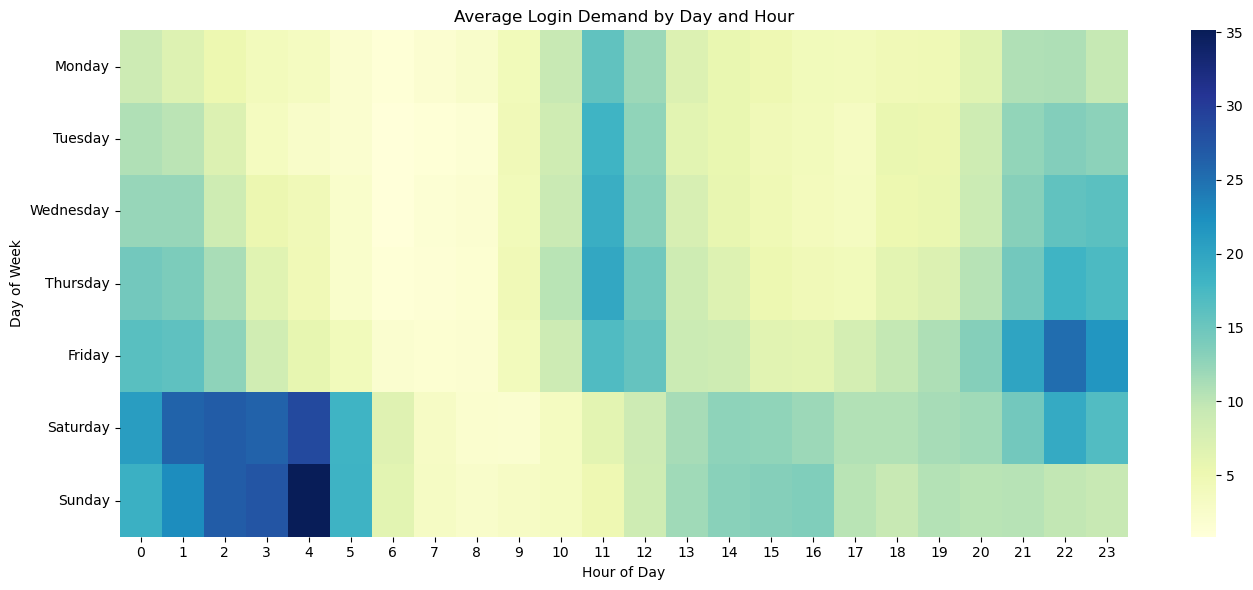

In [21]:
heatmap_data = (
    login_counts.groupby(["day_name", "hour"])["login_count"]
    .mean()
    .reset_index()
    .pivot(index="day_name", columns="hour", values="login_count")
)

heatmap_data = heatmap_data.reindex([
    "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"
])

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Average Login Demand by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

### Weekday vs. Weekend Login Patterns

The final comparison separates weekday demand from weekend demand and plots the hourly pattern for each. This makes it easier to see whether users behave differently on weekends than on weekdays, particularly during late-night and early-morning hours. It also helps clarify whether the strongest peaks are driven by regular weekday routines or by weekend activity.

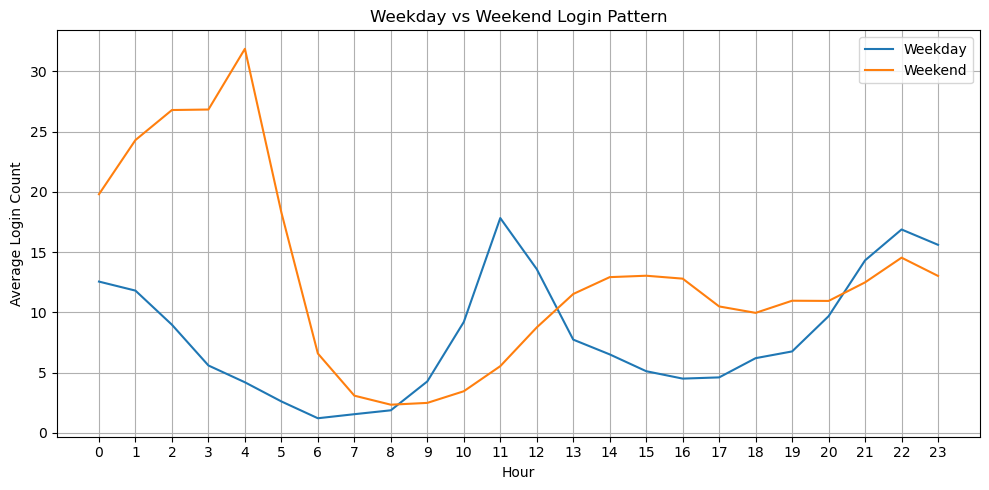

In [23]:
login_counts["is_weekend"] = login_counts["day_of_week"] >= 5

weekpart_hour = login_counts.groupby(["is_weekend", "hour"])["login_count"].mean().reset_index()

plt.figure(figsize=(10,5))
for weekend_flag, label in [(False, "Weekday"), (True, "Weekend")]:
    subset = weekpart_hour[weekpart_hour["is_weekend"] == weekend_flag]
    plt.plot(subset["hour"], subset["login_count"], label=label)

plt.title("Weekday vs Weekend Login Pattern")
plt.xlabel("Hour")
plt.ylabel("Average Login Count")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Part 1 Findings

The login data shows a strong cyclical demand pattern rather than random noise. After aggregating the events into 15-minute intervals, the series reveals clear daily and weekly seasonality. Demand tends to be lowest in the early morning, especially around 7:00–8:00 AM, and much stronger later in the day and overnight.

The hourly analysis shows that activity is highest during the late evening and overnight hours, with especially strong average demand around 10:00 PM through 2:00 AM. Interestingly, weekday demand also remains elevated around late morning to midday, suggesting there may be both commuting or daytime usage and a separate nighttime usage pattern. This indicates that demand is not concentrated in only one part of the day.

The day-of-week analysis shows a clear weekly effect. Average login activity increases as the week progresses, with Friday, Saturday, and Sunday showing the strongest demand. The weekend effect is especially pronounced in the heatmap and the weekday-versus-weekend comparison, where the most intense activity appears during the early morning hours on Saturday and Sunday, especially between about 1:00 AM and 4:00 AM. This suggests that late-night weekend behavior is a major driver of demand.

In terms of data quality, the dataset does not appear to have missing timestamps after loading, and the time range spans from January 1, 1970 through April 13, 1970. There are duplicate timestamps present, but these are not necessarily data errors because multiple users could have logged in at the exact same second. Overall, the data appears usable for time-series analysis, with the main caveat being that duplicate timestamps should be interpreted as concurrent events rather than necessarily as bad records.

## Part 2: Experiment and Metrics Design

### 1) What would you choose as the key measure of success of this experiment in encouraging driver partners to serve both cities, and why would you choose this metric?

The key measure of success for this experiment should be the share of active driver partners who complete trips in both Gotham and Metropolis during the experiment period. This is the strongest primary metric because it directly captures the behavioral change the policy is trying to create. The purpose of reimbursing tolls is not simply to increase total trips, but to reduce geographic exclusivity and encourage drivers to operate across both cities. A metric tied directly to cross-city participation is therefore more appropriate than a broader measure such as total ride volume alone. As secondary metrics, I would also track driver earnings, rider wait times, trip completion rates, and the total cost of reimbursement in order to determine whether the experiment improves marketplace efficiency in a financially sustainable way.

### 2) Describe a practical experiment you would design to compare the effectiveness of the proposed change in relation to the key measure of success. Please provide details on:
### a) how you will implement the experiment

To evaluate the policy, I would run a randomized controlled experiment at the driver-partner level. Eligible drivers would be identified based on their likelihood of serving either city, such as those who already operate near the bridge or have historically taken trips close to the city boundary. These drivers would then be randomly assigned into either a treatment group, which receives full toll reimbursement, or a control group, which continues under the existing policy. The experiment should run long enough to capture both weekday and weekend patterns, ideally for several weeks, since the business context suggests that driver behavior differs meaningfully across those periods. Randomization could also be stratified by home city and prior activity level to make sure the treatment and control groups are balanced before the experiment begins.

### 2b) what statistical test(s) you will conduct to verify the significance of the observation

To test whether the proposed change has a meaningful effect, I would compare the treatment and control groups on the primary success metric using a two-proportion z-test if the metric is defined as whether a driver served both cities at least once during the test period. If the metric is instead defined as a continuous measure, such as the share of trips completed outside a driver’s original city, I would use a two-sample t-test and supplement it with a regression model that controls for baseline driver activity and city effects. The purpose of the statistical test would be to determine whether any observed increase in cross-city participation is large enough that it is unlikely to be explained by random chance alone.

### 2c) how you would interpret the results and provide recommendations to the city operations team along with any caveats.

I would interpret the results by first asking whether the treatment group shows a statistically significant and operationally meaningful improvement in cross-city driving behavior. If the reimbursement policy increases cross-city participation and also improves rider-side metrics such as lower wait times or better trip fulfillment, then I would recommend broader rollout, assuming the financial cost of the reimbursements is justified by the operational gains. If the treatment increases cross-city participation but the cost is too high relative to the benefit, I would recommend a narrower rollout targeted to specific hours, days, or driver segments where supply imbalances are most severe. If the experiment shows no significant change, I would recommend against a universal reimbursement program and instead suggest testing a more targeted incentive design. Important caveats include possible spillover effects between treated and untreated drivers, short-term behavior changes that may not persist over time, and external demand fluctuations that could influence results independently of the toll policy.

## Part 3 – Predictive Modeling

The objective of this section is to analyze rider retention and build a predictive model that identifies which users are likely to remain active on the platform. A user is considered "retained" if they were active (i.e., took at least one trip) within the 30 days preceding the observation period.

This section will include:
- Data cleaning and preparation
- Exploratory data analysis (EDA)
- Model development and evaluation
- Key insights and business recommendations

### Data Loading and Initial Inspection

We begin by loading the dataset and examining its structure, including data types, missing values, and general distributions. This helps identify any data quality issues that need to be addressed before modeling.

In [32]:
ultimate = pd.read_json("ultimate_data_challenge.json")

ultimate.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [33]:
ultimate.info()
ultimate.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
dtype: int64

In [34]:
ultimate.describe(include="all")

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
count,50000,50000.000000,50000,41878.000000,50000.000000,50000,49604,50000.000000,50000,50000.000000,50000.000000,49799.000000
unique,3,NaN,31,NaN,NaN,182,2,NaN,2,NaN,NaN,NaN
top,Winterfell,NaN,2014-01-18,NaN,NaN,2014-06-29,iPhone,NaN,False,NaN,NaN,NaN
freq,23336,NaN,2948,NaN,NaN,2036,34582,NaN,31146,NaN,NaN,NaN
mean,NaN,2.278200,NaN,4.601559,1.074764,NaN,NaN,8.849536,NaN,60.926084,5.796827,4.778158
std,NaN,3.792684,NaN,0.617338,0.222336,NaN,NaN,19.958811,NaN,37.081503,5.707357,0.446652
min,NaN,0.000000,NaN,1.000000,1.000000,NaN,NaN,0.000000,NaN,0.000000,0.000000,1.000000
25%,NaN,0.000000,NaN,4.300000,1.000000,NaN,NaN,0.000000,NaN,33.300000,2.420000,4.700000
50%,NaN,1.000000,NaN,4.900000,1.000000,NaN,NaN,0.000000,NaN,66.700000,3.880000,5.000000
75%,NaN,3.000000,NaN,5.000000,1.050000,NaN,NaN,8.600000,NaN,100.000000,6.940000,5.000000


### Defining the Target Variable (Retention)

Retention is defined as whether a user was active in the 30 days preceding the end of the observation period. To operationalize this, we use the most recent `last_trip_date` in the dataset as the reference point.

Users whose last trip occurred within the final 30 days are labeled as "retained," while others are considered churned.

In [36]:
ultimate["signup_date"] = pd.to_datetime(ultimate["signup_date"])
ultimate["last_trip_date"] = pd.to_datetime(ultimate["last_trip_date"])

obs_end = ultimate["last_trip_date"].max()

ultimate["retained"] = (
    ultimate["last_trip_date"] >= (obs_end - pd.Timedelta(days=30))
).astype(int)

retention_rate = ultimate["retained"].mean()
print("Retention Rate:", retention_rate)

Retention Rate: 0.37608


Approximately 38% of users in the dataset are retained based on this definition. This provides a baseline understanding of user retention and highlights the potential for improvement through targeted interventions.

### Data Cleaning and Preparation

Before building predictive models, we address missing values and prepare the dataset for analysis.

- Numerical missing values are imputed using the median to reduce sensitivity to outliers.
- Categorical missing values are imputed using the most frequent category.
- Date fields are converted to datetime format.
- The `last_trip_date` variable is excluded from modeling to prevent data leakage, as it is used to define the target variable.

In [39]:
df = ultimate.copy()

# Drop leakage columns later
# Identify feature columns
X = df.drop(columns=["retained", "last_trip_date", "signup_date"])
y = df["retained"]

### Exploratory Data Analysis

We explore relationships between key features and retention to identify patterns that may inform model development and business decisions.

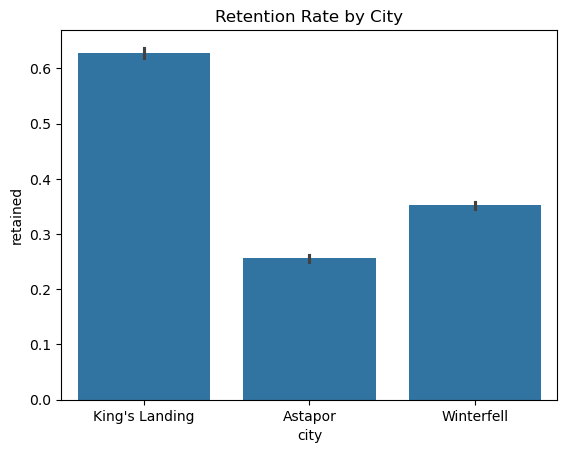

In [41]:
sns.barplot(data=df, x="city", y="retained")
plt.title("Retention Rate by City")
plt.show()

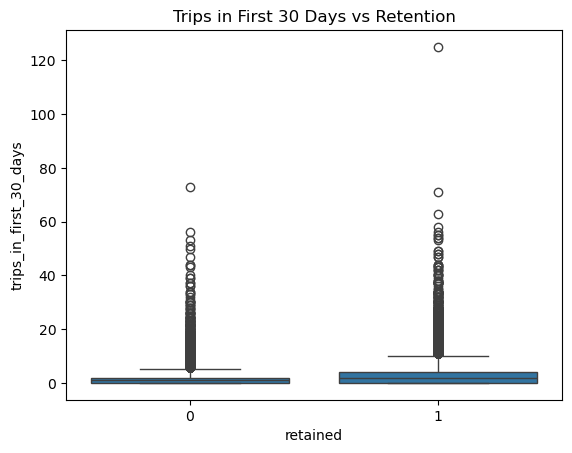

In [42]:
sns.boxplot(data=df, x="retained", y="trips_in_first_30_days")
plt.title("Trips in First 30 Days vs Retention")
plt.show()

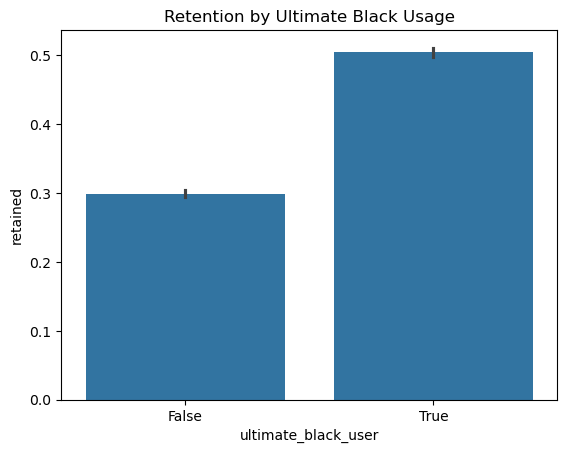

In [43]:
sns.barplot(data=df, x="ultimate_black_user", y="retained")
plt.title("Retention by Ultimate Black Usage")
plt.show()

Several key patterns emerge from the exploratory analysis:

- Users with higher activity in their first 30 days tend to have significantly higher retention rates.
- Premium service usage (e.g., Ultimate Black) appears positively associated with retention.
- Differences across cities suggest that geographic factors may influence long-term engagement.

These findings suggest that early user behavior is a strong indicator of long-term retention.

### Data Preparation for Modeling

We split the dataset into training and testing sets and apply preprocessing steps including imputation, scaling, and encoding. This ensures the model can generalize well to unseen data.

In [46]:
from sklearn.model_selection import train_test_split

categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Model Development

We first implement a Logistic Regression model due to its interpretability and suitability for binary classification problems. We also compare it with a Random Forest model to capture potential nonlinear relationships.

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['trips_in_first_30_days',
                                                   'avg_rating_of_driver',
                                                   'avg_surge', 'surge_pct',
                                                   'weekday_pct', 'avg_dist',
                                                   'avg_rating_by_driver']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city', 'phone',
                                                   'ultimate_black_user'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['trips_in_first_30_days',
                                                   'avg_rating_of_driver',
                                                   'avg_surge', 'surge_pct',
                                                   'weekday_pct', 'avg_dist',
                                                   'avg_rating_by_driver']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city', 'phone',
                                                   'ultimate_black_user'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

### Model Evaluation

We evaluate model performance using multiple metrics, including accuracy, precision, recall, F1-score, and ROC-AUC. These metrics provide a comprehensive understanding of predictive performance.

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Logistic Regression:
Accuracy: 0.7148
Precision: 0.6635480388629004
Recall: 0.4902951342727998
F1: 0.563914373088685
ROC-AUC: 0.7537183123765523


In [82]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Random Forest:
Accuracy: 0.7581
Precision: 0.685666851134477
Recall: 0.6588673225206062
F1: 0.672
ROC-AUC: 0.8264082461281818


The Logistic Regression model provides a strong and interpretable baseline for predicting rider retention. The Random Forest model was evaluated as a nonlinear alternative to capture more complex relationships in the data.

Comparing the two models, the Random Forest model outperforms Logistic Regression across all evaluation metrics. It achieves higher accuracy (0.758 vs. 0.715), higher recall (0.659 vs. 0.490), and a significantly higher ROC-AUC score (0.826 vs. 0.754), indicating better overall predictive performance and improved ability to correctly identify retained users.

While Logistic Regression remains valuable due to its interpretability, the Random Forest model is the stronger choice for prediction in this case, as it captures nonlinear patterns and provides more accurate and balanced performance.

### Key Predictors of Retention

Based on the exploratory analysis and the model inputs, the strongest candidate predictors of retention appear to include:

- Early user engagement (trips in the first 30 days)
- Usage of premium services (Ultimate Black)
- User activity patterns (weekday usage, surge behavior)
- Geographic location (city)

These factors highlight the importance of early user experience in driving long-term retention.

### Business Recommendations

Ultimate can leverage these insights to improve long-term rider retention through several strategies:

- Encourage early engagement by incentivizing users to take more trips within their first 30 days.
- Promote premium services such as Ultimate Black, which are associated with higher retention.
- Identify at-risk users early and target them with personalized incentives or promotions.
- Tailor strategies by city to account for regional differences in user behavior.

By focusing on early lifecycle engagement and targeted interventions, Ultimate can improve retention and maximize customer lifetime value.

### Limitations

While the model provides valuable insights, several limitations should be considered:

- Retention is defined based on a fixed observation window, which may not capture long-term behavior.
- The dataset represents a single cohort, limiting generalizability.
- Some features may be correlated but not causal.
- Class imbalance may impact model performance.

Future work could incorporate additional data sources and more advanced modeling techniques to improve predictive accuracy.